In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

import torch
from torch import optim
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch.nn.functional as F

import torchmetrics

import librosa
from IPython.display import Audio
from pathlib import Path
from tqdm import tqdm
import json
import traceback
import ast
import os


from sklearn.metrics import roc_auc_score




In [2]:

import seaborn as sns
import torch
from torch.utils.data import DataLoader

from src.metadata import load_metadata_artifacts
from src.train import build_manifest_with_splits
from src.sequence_dataset import SpectrogramClipDataset, collate_spectrogram_batch
from src.model import BirdCLEFSpectrogramModel


# Loading Data and Pre-Processing
## importing data, dropping noisy columns, fetching audio data

In [3]:
train = pd.read_csv('train.csv')

In [4]:
train_soundscapes = pd.read_csv('train_soundscapes_labels.csv')

In [5]:
train.shape

(35549, 15)

In [6]:
train1 = train.copy()

In [7]:
train2 = train1.copy()

In [8]:
#adding the full path to fetch the audio
base_path = "train_audio"

train2['full_path'] = train2['filename'].apply(lambda x: os.path.join(base_path, x))
train_soundscapes['full_path'] = train_soundscapes['filename'].apply(lambda x: os.path.join(base_path, x))

In [9]:
train3 = train2.copy()
train_soundscapes1 = train_soundscapes.copy()

In [10]:
train4 = train3.drop(columns =['collection', 'author', 'license', 'url', 'inat_taxon_id', 'common_name', 'type'])

In [11]:
train4

,primary_label,secondary_labels,latitude,longitude,scientific_name,class_name,rating,filename,full_path
0,1161364,[],-22.7562,-46.8666,Guyalna cuta,Insecta,0.0,1161364/iNat1216197.ogg,train_audio/1161364/iNat1216197.ogg
1,1161364,[],-22.7558,-46.8700,Guyalna cuta,Insecta,0.0,1161364/iNat1114648.ogg,train_audio/1161364/iNat1114648.ogg
2,1161364,[],-22.7547,-46.8728,Guyalna cuta,Insecta,0.0,1161364/iNat810195.ogg,train_audio/1161364/iNat810195.ogg
3,1161364,[],-22.7547,-46.8728,Guyalna cuta,Insecta,0.0,1161364/iNat818781.ogg,train_audio/1161364/iNat818781.ogg
4,1161364,[],-22.7426,-46.8985,Guyalna cuta,Insecta,0.0,1161364/iNat556514.ogg,train_audio/1161364/iNat556514.ogg
...,...,...,...,...,...,...,...,...,...
35544,yeofly1,[],-6.7281,-76.4181,Tolmomyias sulphurescens,Aves,4.0,yeofly1/XC762473.ogg,train_audio/yeofly1/XC762473.ogg
35545,yeofly1,[],-16.0538,-49.6040,Tolmomyias sulphurescens,Aves,5.0,yeofly1/XC818328.ogg,train_audio/yeofly1/XC818328.ogg
35546,yeofly1,[],5.9002,-74.8485,Tolmomyias sulphurescens,Aves,4.0,yeofly1/XC425545.ogg,train_audio/yeofly1/XC425545.ogg
35547,yeofly1,[],3.3821,-61.4464,Tolmomyias sulphurescens,Aves,4.0,yeofly1/XC456230.ogg,train_audio/yeofly1/XC456230.ogg


In [12]:
#example
Audio_Path = "/Users/sauravbellam/Desktop/Projects/audio classification/birdclef-2026 2/birdclef_fresh_start/train_audio/"

y, sr = librosa.load(Audio_Path + "1161364/iNat1216197.ogg", sr=32000)

Audio(y, rate=sr)

In [13]:
from src.metadata import load_metadata_artifacts
from src.labels import encode_labels

meta = load_metadata_artifacts(".", input_dir="splits")
master_df = meta["master_df"]

def encode_fn(labels):
    return encode_labels(labels, label_to_idx, num_classes)

In [14]:
from src.metadata import build_taxonomy_mapping
BASE_DIR = Path("/Users/sauravbellam/Desktop/Projects/audio classification/birdclef-2026 2/birdclef_fresh_start")


taxonomy_df = build_taxonomy_mapping(BASE_DIR)
taxonomy_df.head()


,primary_label,scientific_name,common_name,genus_name,family_name
0,1161364,Guyalna cuta,Guyalna cuta,guyalna,insecta
1,116570,Caiman yacare,Southern Spectacled Caiman,caiman,reptilia
2,1176823,Leptodactylus luctator,Wrestler Frog,leptodactylus,amphibia
3,1491113,Adenomera guarani,Guaraní leaf-litter frog,adenomera,amphibia
4,1595929,Lysapsus limellum,Uruguay Harlequin Frog,lysapsus,amphibia


In [15]:
from collections import Counter

label_counts = Counter(
    label
    for labels in master_df["all_labels"]
    for label in labels
)

class_counts_df = (
    pd.DataFrame(
        sorted(label_counts.items(), key=lambda x: x[1], reverse=True),
        columns=["label", "count"]
    )
)

print(class_counts_df.shape)
class_counts_df.head(20)

print(class_counts_df["count"].describe())


(169, 2)
count    169.000000
mean      62.076923
std      120.059608
min        1.000000
25%        4.000000
50%       11.000000
75%       59.000000
max      666.000000
Name: count, dtype: float64


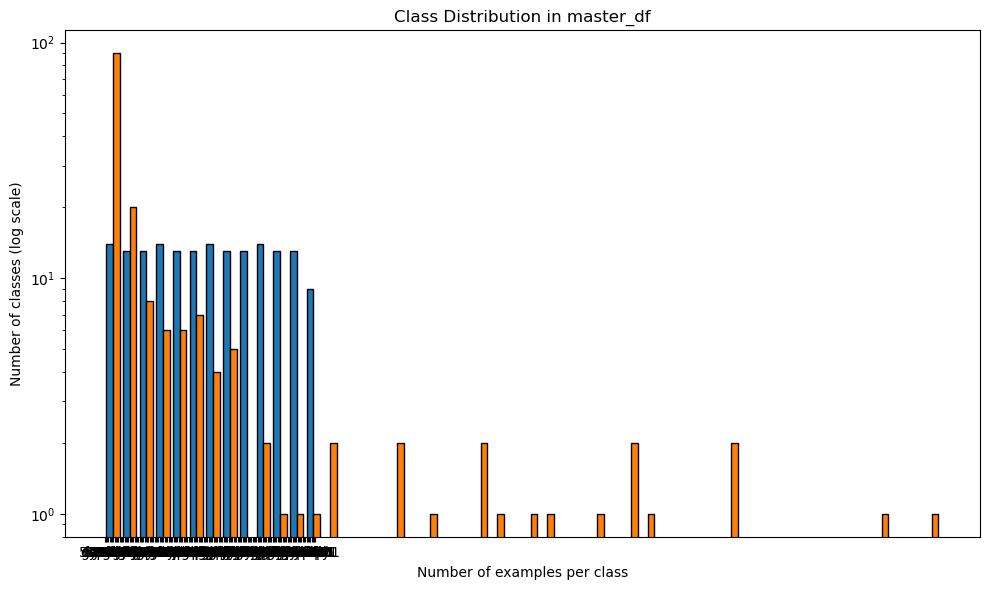

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(class_counts_df, bins=50, edgecolor="black")
plt.yscale("log")
plt.xlabel("Number of examples per class")
plt.ylabel("Number of classes (log scale)")
plt.title("Class Distribution in master_df")
plt.tight_layout()
plt.show()


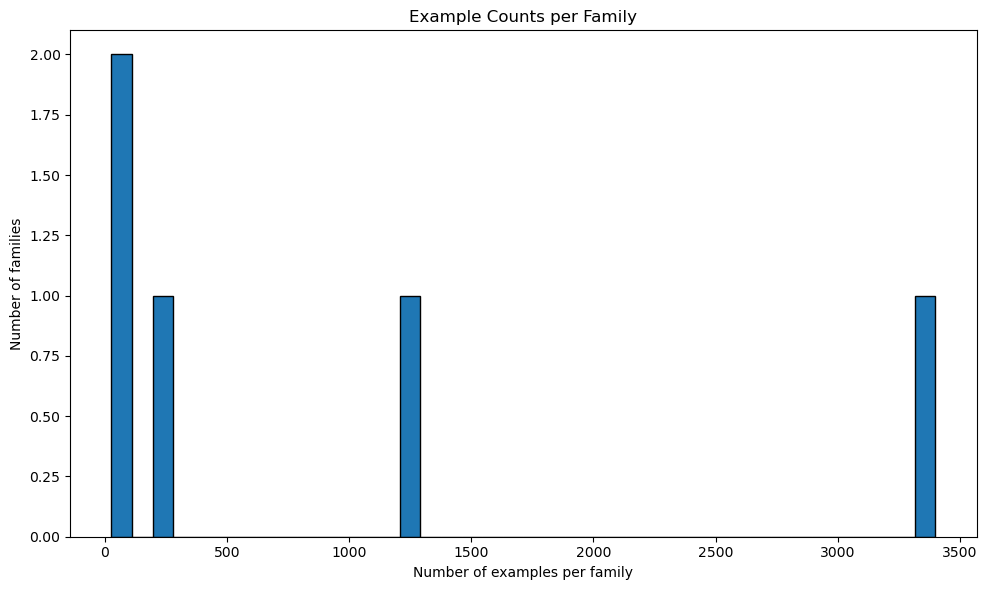

In [20]:
family_example_counts = (
    master_df["family_name"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
plt.hist(family_example_counts.values, bins=40, edgecolor="black")
plt.xlabel("Number of examples per family")
plt.ylabel("Number of families")
plt.title("Example Counts per Family")
plt.tight_layout()
plt.show()

In [21]:
family_example_counts = (
    master_df["family_name"]
    .value_counts()
    .sort_values(ascending=True)
)

family_example_counts.head(20)


family_name
reptilia      27
mammalia      98
insecta      247
amphibia    1249
aves        3400
Name: count, dtype: int64

In [22]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt



clean_df = master_df[master_df["phase_group"] == "clean"].copy()
semi_df = master_df[master_df["phase_group"] == "semi"].copy()
noisy_df = master_df[master_df["phase_group"] == "noisy"].copy()
soundscape_df = master_df[master_df["phase_group"] == "soundscape"].copy()

def class_count_df(df):
    return (
        df["all_labels"]
        .explode()
        .value_counts()
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"index": "label", "all_labels": "count"})
    )

clean_counts = class_count_df(master_df[master_df["phase_group"] == "clean"])
semi_counts = class_count_df(master_df[master_df["phase_group"] == "semi"])
noisy_counts = class_count_df(master_df[master_df["phase_group"] == "noisy"])
soundscape_counts = class_count_df(master_df[master_df["phase_group"] == "soundscape"])


In [23]:
# Most common classes
print(clean_counts.head(20))

# Rarest classes
print(clean_counts.tail(20))

      count  count
0    saffin     82
1   rumfly1     77
2   gycwor1     71
3    fepowl     65
4   rebscy1     63
5    greela     49
6    redjun     47
7   recfin1     41
8   ragmac1     38
9   yebela1     38
10  whnjay1     35
11  grhtan1     33
12  purjay1     32
13  rufcas2     19
14  blchaw1     14
15   shshaw      6
16  ruther1      4
17    47144      2
18   738183      1
      count  count
0    saffin     82
1   rumfly1     77
2   gycwor1     71
3    fepowl     65
4   rebscy1     63
5    greela     49
6    redjun     47
7   recfin1     41
8   ragmac1     38
9   yebela1     38
10  whnjay1     35
11  grhtan1     33
12  purjay1     32
13  rufcas2     19
14  blchaw1     14
15   shshaw      6
16  ruther1      4
17    47144      2
18   738183      1


In [24]:
import pandas as pd

family_phase_counts = {
    phase: (
        master_df[master_df["phase_group"] == phase]["family_name"]
        .value_counts()
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"index": "family", "family_name": "count"})
    )
    for phase in ["clean", "semi", "noisy", "soundscape"]
}

In [25]:
for phase, df in family_phase_counts.items():
    print(f"\n{phase.upper()} (ALL families):")
    print(df)


CLEAN (ALL families):
      count  count
0      aves    714
1  mammalia      3

SEMI (ALL families):
      count  count
0      aves   1489
1  amphibia      9
2  mammalia      1

NOISY (ALL families):
      count  count
0      aves   1167
1  amphibia    108
2  mammalia     44
3   insecta      7
4  reptilia      1

SOUNDSCAPE (ALL families):
      count  count
0  amphibia   1132
1   insecta    240
2  mammalia     50
3      aves     30
4  reptilia     26


## Encoding Labels

In [31]:
train_soundscapes1['label_list'] = train_soundscapes['primary_label'].apply(lambda x: x.split(';'))

In [32]:
train_soundscapes2 = train_soundscapes1.copy()

In [33]:
#one dict of all species
train_species = set(train['primary_label'].unique())
soundscape_species = set(label for labels in train_soundscapes1['label_list'] for label in labels)

all_species = sorted(train_species | soundscape_species)
species_to_idx = {species: i for i, species in enumerate(all_species)}
idx_to_species = {i: species for species, i in species_to_idx.items()}

In [34]:
#secondary labels
import ast

def parse_secondary(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return []

train4['secondary_labels'] = train4['secondary_labels'].apply(parse_secondary)

In [35]:
train4['all_labels'] = train4.apply(
    lambda row: [row['primary_label']] + row['secondary_labels'],
    axis=1
)

In [36]:
#encode train
def encode_multi(labels, species_to_idx):
    vec = np.zeros(len(species_to_idx), dtype=np.float32)
    for label in labels:
        if label in species_to_idx:
            vec[species_to_idx[label]] = 1.0
    return vec

train4['target'] = train4['all_labels'].apply(
    lambda x: encode_multi(x, species_to_idx)
)

In [37]:
#encode soundscape
def encode_multi(labels, species_to_idx):
    vec = np.zeros(len(species_to_idx), dtype=np.float32)
    for label in labels:
        if label in species_to_idx:
            vec[species_to_idx[label]] = 1.0
    return vec

train_soundscapes2['target'] = train_soundscapes1['label_list'].apply(
    lambda x: encode_multi(x, species_to_idx)
)

In [38]:
train4.shape

(35549, 11)

In [39]:
BASE_PATH = "."

In [40]:
def build_path(row):
    try:
        filename = row['filename'].split('/')[-1]
        label = row['primary_label']

        if not isinstance(label, str):
            return None

        return os.path.join(
            BASE_PATH,
            "train_audio",
            label,
            filename
        )

    except:
        return None

In [41]:
#cleanest data
rate5 = train4[train4['rating'] == 5]

In [42]:
rate5['primary_label'].value_counts().min()

1

In [43]:
#low end 
counts = rate5['primary_label'].value_counts()

counts.describe()

count    173.000000
mean      39.566474
std       29.778688
min        1.000000
25%       18.000000
50%       32.000000
75%       56.000000
max      142.000000
Name: count, dtype: float64

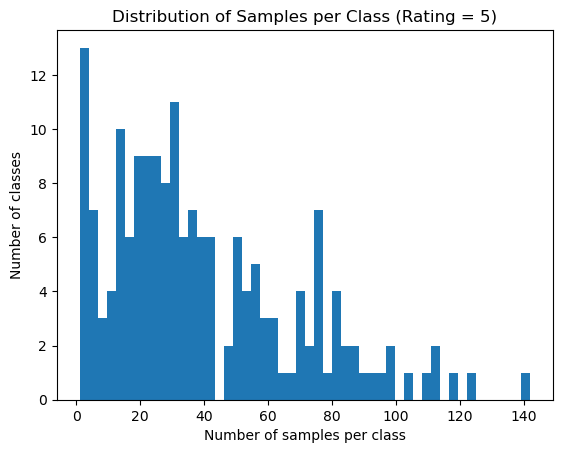

In [44]:
import matplotlib.pyplot as plt

plt.hist(counts, bins=50)
plt.title("Distribution of Samples per Class (Rating = 5)")
plt.xlabel("Number of samples per class")
plt.ylabel("Number of classes")
plt.show()

In [45]:
import ast

def parse_secondary(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return []


In [46]:
secondary = train4[train4['secondary_labels'].apply(lambda x: len(x) > 0)]

In [47]:
secondary_low = secondary[secondary['rating'] < 3]

# Model Preformance

In [48]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("/Users/sauravbellam/Desktop/Projects/audio classification/birdclef-2026 2/birdclef_fresh_start/vm_final_results/final_train_test")
EPOCH_HISTORY_PATH = RESULTS_DIR / "epoch_history.jsonl"

rows = []
with EPOCH_HISTORY_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        row = json.loads(line)
        rows.append({
            "global_epoch": row["global_epoch"],
            "phase_name": row["phase_name"],
            "phase_epoch": row["phase_epoch"],
            "lr": row["lr"],
            "train_loss": row["train_loss"],
            "val_loss": row["val_loss"],
            "train_macro_roc_auc": row["train_metrics"]["macro_roc_auc"],
            "val_macro_roc_auc": row["val_metrics"]["macro_roc_auc"],
            "train_macro_pr_auc": row["train_metrics"]["macro_pr_auc"],
            "val_macro_pr_auc": row["val_metrics"]["macro_pr_auc"],
        })

epoch_df = pd.DataFrame(rows)
epoch_df.head()


,global_epoch,phase_name,phase_epoch,lr,train_loss,val_loss,train_macro_roc_auc,val_macro_roc_auc,train_macro_pr_auc,val_macro_pr_auc
0,1,phase1,1,0.001,0.205026,0.062613,0.488594,0.598242,0.080140,0.038834
1,2,phase1,2,0.001,0.063286,0.061264,0.488779,0.483642,0.092219,0.039756


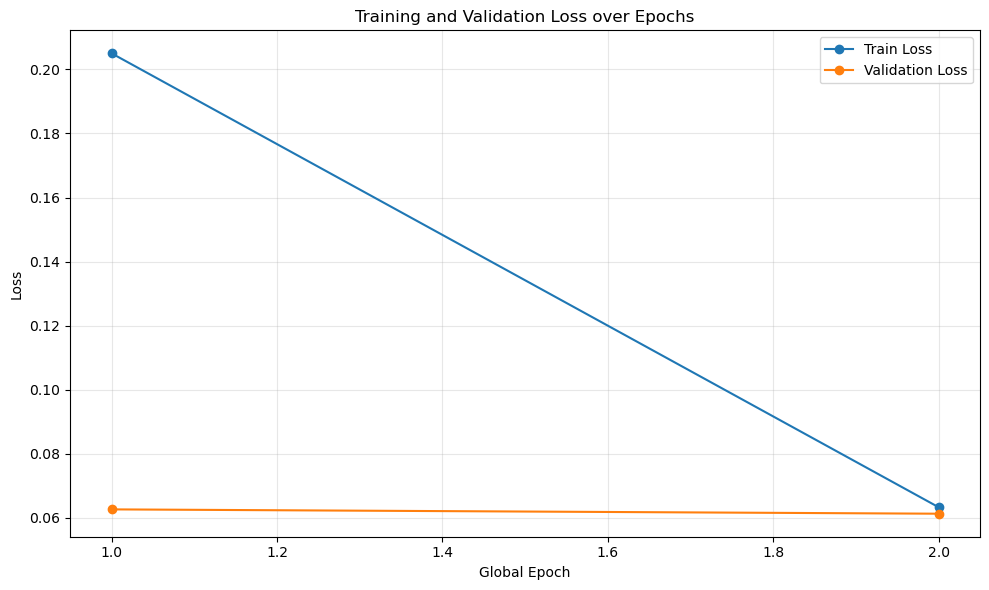

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(epoch_df["global_epoch"], epoch_df["train_loss"], marker="o", label="Train Loss")
plt.plot(epoch_df["global_epoch"], epoch_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Global Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss over Epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


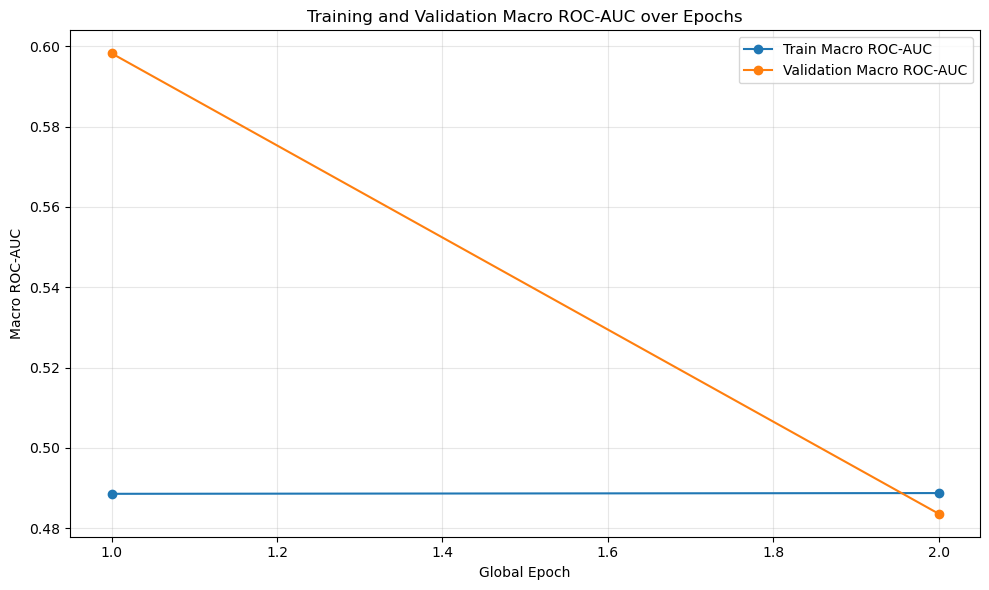

In [50]:
plt.figure(figsize=(10, 6))
plt.plot(epoch_df["global_epoch"], epoch_df["train_macro_roc_auc"], marker="o", label="Train Macro ROC-AUC")
plt.plot(epoch_df["global_epoch"], epoch_df["val_macro_roc_auc"], marker="o", label="Validation Macro ROC-AUC")
plt.xlabel("Global Epoch")
plt.ylabel("Macro ROC-AUC")
plt.title("Training and Validation Macro ROC-AUC over Epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Attention Heat Map

In [51]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

BASE_DIR = Path("/Users/sauravbellam/Desktop/Projects/audio classification/birdclef-2026 2/birdclef_fresh_start")

CLASS_LIST_PATH = BASE_DIR / "splits" / "class_list.json"
MANIFEST_PATH = BASE_DIR / "stage1_precompute" / "manifest.csv"

with CLASS_LIST_PATH.open("r", encoding="utf-8") as f:
    class_list = json.load(f)

label_to_idx = {label: i for i, label in enumerate(class_list)}
idx_to_label = {i: label for label, i in label_to_idx.items()}

manifest_df = pd.read_csv(MANIFEST_PATH)

def encode_labels(labels, label_to_idx):
    y = np.zeros(len(label_to_idx), dtype=np.float32)
    for label in labels:
        if label in label_to_idx:
            y[label_to_idx[label]] = 1.0
    return y

def decode_species_labels(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        value = value.strip()
        if not value:
            return []
        try:
            parsed = json.loads(value)
            return parsed if isinstance(parsed, list) else [value]
        except json.JSONDecodeError:
            return [value]
    return []

manifest_df["species_labels"] = manifest_df.get("species_labels", manifest_df["primary_label"]).apply(
    lambda x: json.dumps([str(x)]) if not isinstance(x, str) or not x.startswith("[") else x
)

manifest_df["decoded_labels"] = manifest_df["species_labels"].apply(decode_species_labels)
manifest_df["encoded_labels"] = manifest_df["decoded_labels"].apply(lambda x: encode_labels(x, label_to_idx))

manifest_df.head()


,clip_id,source_file_id,source_row_id,record_path,full_path,phase_group,is_soundscape,split_role,cv_fold,clip_index,clip_start_sec,clip_end_sec,clip_duration_sec,primary_label,num_species_labels,spectrogram_shape,status,species_labels,decoded_labels,encoded_labels
0,iNat1460166_clip_0000,iNat1460166,iNat1460166__full,stage1_precompute/iNat1460166_clip_0000.npz,train_audio/116570/iNat1460166.ogg,train_audio,False,trainval,-1,0,0.0,5.0,5.0,116570,1,"[3, 128, 384]",computed,"[""116570""]",[116570],"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,iNat1460166_clip_0001,iNat1460166,iNat1460166__full,stage1_precompute/iNat1460166_clip_0001.npz,train_audio/116570/iNat1460166.ogg,train_audio,False,trainval,-1,1,5.0,10.0,5.0,116570,1,"[3, 128, 384]",computed,"[""116570""]",[116570],"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,iNat347848_clip_0000,iNat347848,iNat347848__full,stage1_precompute/iNat347848_clip_0000.npz,train_audio/22983/iNat347848.ogg,train_audio,False,trainval,-1,0,0.0,5.0,5.0,22983,1,"[3, 128, 384]",computed,"[""22983""]",[22983],"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."
3,iNat347848_clip_0001,iNat347848,iNat347848__full,stage1_precompute/iNat347848_clip_0001.npz,train_audio/22983/iNat347848.ogg,train_audio,False,trainval,-1,1,5.0,10.0,5.0,22983,1,"[3, 128, 384]",computed,"[""22983""]",[22983],"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."
4,iNat347848_clip_0002,iNat347848,iNat347848__full,stage1_precompute/iNat347848_clip_0002.npz,train_audio/22983/iNat347848.ogg,train_audio,False,trainval,-1,2,10.0,15.0,5.0,22983,1,"[3, 128, 384]",computed,"[""22983""]",[22983],"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."


In [52]:
SOURCE_ROW_ID = "XC1001088__full"

sample_df = (
    manifest_df[manifest_df["source_row_id"] == SOURCE_ROW_ID]
    .sort_values("clip_index")
    .reset_index(drop=True)
    .copy()
)

if "family_name" not in sample_df.columns:
    sample_df["family_name"] = "unknown_family"

sample_df[["clip_id", "clip_index", "record_path", "species_labels"]]


,clip_id,clip_index,record_path,species_labels
0,XC1001088_clip_0000,0,stage1_precompute/XC1001088_clip_0000.npz,"[""rumfly1""]"
1,XC1001088_clip_0001,1,stage1_precompute/XC1001088_clip_0001.npz,"[""rumfly1""]"


In [54]:
import json
from pathlib import Path

import pandas as pd
import torch

from src.model import BirdCLEFSpectrogramModel
from src.sequence_dataset import SpectrogramClipDataset, collate_spectrogram_batch

BASE_DIR = Path("/Users/sauravbellam/Desktop/Projects/audio classification/birdclef-2026 2/birdclef_fresh_start")
CHECKPOINT_PATH = BASE_DIR / "vm_final_results" / "final_train_test" / "checkpoints" / "final_model.pt"
MANIFEST_PATH = BASE_DIR / "stage1_precompute" / "manifest.csv"
CLASS_LIST_PATH = BASE_DIR / "splits" / "class_list.json"

SOURCE_ROW_ID = "XC1001088__full"
MAX_CLIPS_PER_SEQUENCE = 8

with CLASS_LIST_PATH.open("r", encoding="utf-8") as f:
    class_list = json.load(f)

label_to_idx = {label: i for i, label in enumerate(class_list)}
idx_to_label = {i: label for label, i in label_to_idx.items()}

manifest_df = pd.read_csv(MANIFEST_PATH)
sample_df = (
    manifest_df[manifest_df["source_row_id"] == SOURCE_ROW_ID]
    .sort_values("clip_index")
    .reset_index(drop=True)
    .copy()
)

if "species_labels" not in sample_df.columns:
    sample_df["species_labels"] = sample_df["primary_label"].apply(lambda x: json.dumps([str(x)]))
if "family_name" not in sample_df.columns:
    sample_df["family_name"] = "unknown_family"

ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=True)
config = ckpt["config"]

model = BirdCLEFSpectrogramModel(
    num_classes=len(label_to_idx),
    base_channels=int(config["base_channels"]),
    hidden_dim=int(config["hidden_dim"]),
    dropout=float(config["dropout"]),
    pooling_type=str(config["pooling_type"]),
    topk_ratio=float(config.get("topk_ratio", 0.2)),
)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

dataset = SpectrogramClipDataset(
    manifest_source=sample_df,
    species_to_idx=label_to_idx,
    base_dir=str(BASE_DIR),
    apply_final_augmentation=False,
    enable_reuse_augmentation=False,
    max_clips_per_sequence=MAX_CLIPS_PER_SEQUENCE,
)

sample = dataset[0]
batch = collate_spectrogram_batch([sample])

with torch.no_grad():
    outputs = model(
        spectrogram=batch["spectrogram"],
        clip_mask=batch["clip_mask"],
    )

print(outputs.keys())


dict_keys(['logits', 'probs', 'bag_probs', 'clip_embeddings', 'instance_probs', 'instance_logits', 'bag_embeddings', 'attention_weights', 'clip_mask'])


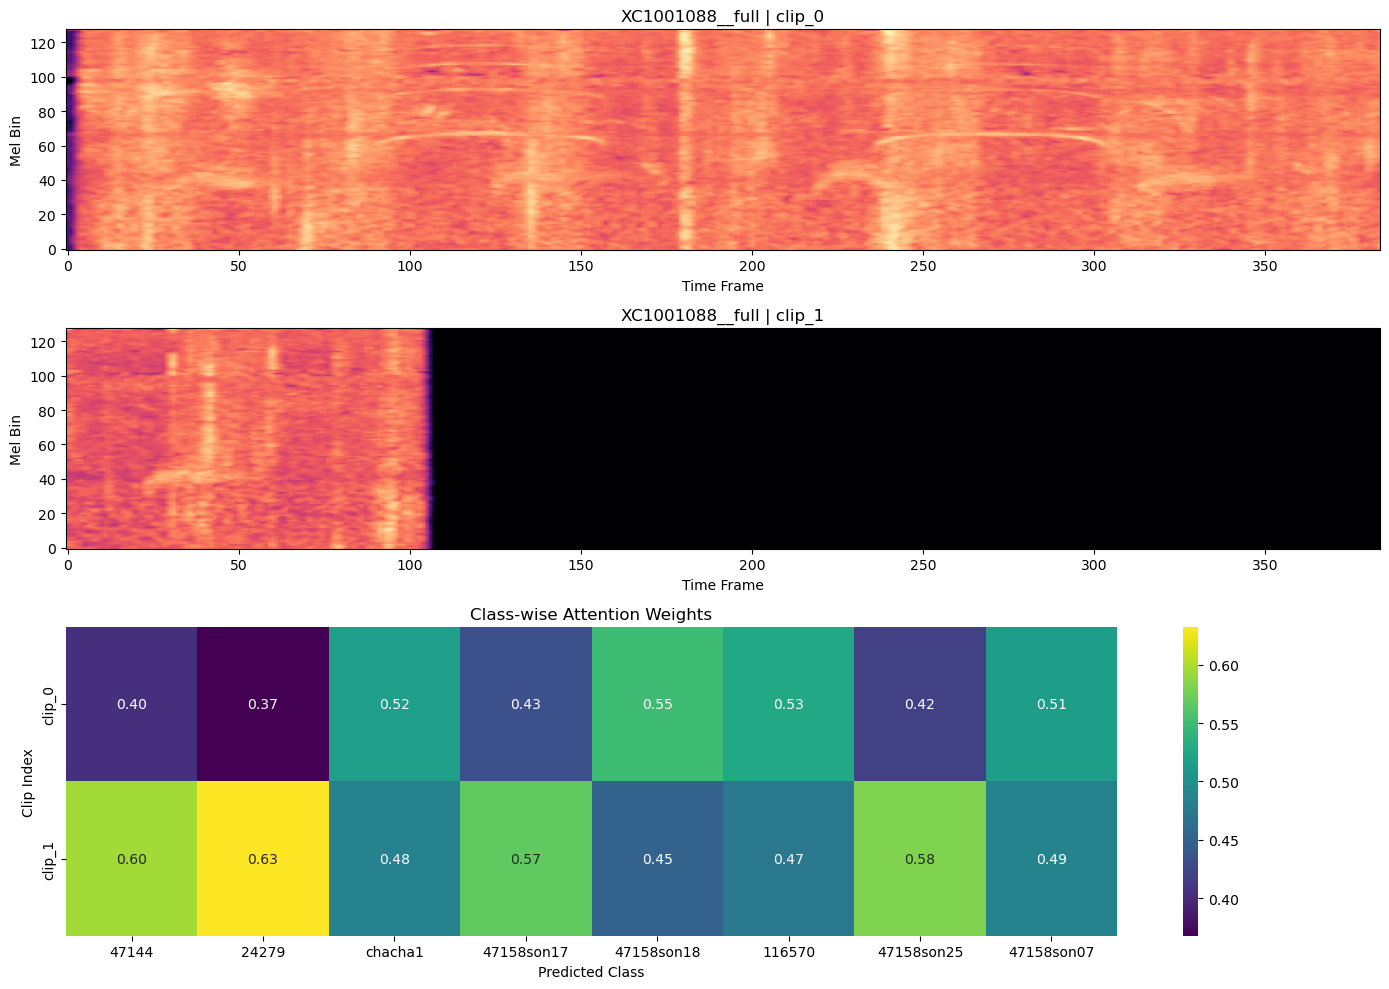

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

attention = outputs["attention_weights"][0].cpu().numpy()   # [num_clips, num_classes]
bag_probs = outputs["probs"][0].cpu().numpy()
clip_mask = outputs["clip_mask"][0].cpu().numpy().astype(bool)
spectrograms = batch["spectrogram"][0].cpu().numpy()        # [num_clips, 3, mel, time]

valid_attention = attention[clip_mask]
valid_spectrograms = spectrograms[clip_mask]
num_valid_clips = valid_attention.shape[0]

top_class_idx = np.argsort(bag_probs)[::-1][:8]
top_class_labels = [idx_to_label[i] for i in top_class_idx]

heatmap_df = pd.DataFrame(
    valid_attention[:, top_class_idx],
    index=[f"clip_{i}" for i in range(num_valid_clips)],
    columns=top_class_labels,
)

fig = plt.figure(figsize=(14, 3 * num_valid_clips + 4))
gs = fig.add_gridspec(
    nrows=num_valid_clips + 1,
    ncols=1,
    height_ratios=[1] * num_valid_clips + [1.4],
)

# Plot one spectrogram per clip
for i in range(num_valid_clips):
    ax = fig.add_subplot(gs[i, 0])
    # channel 0 = log-mel
    ax.imshow(valid_spectrograms[i, 0], aspect="auto", origin="lower", cmap="magma")
    ax.set_title(f"{SOURCE_ROW_ID} | clip_{i}")
    ax.set_ylabel("Mel Bin")
    ax.set_xlabel("Time Frame")

# Plot attention heatmap underneath
ax_heat = fig.add_subplot(gs[-1, 0])
sns.heatmap(
    heatmap_df,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    cbar=True,
    ax=ax_heat,
)
ax_heat.set_title("Class-wise Attention Weights")
ax_heat.set_xlabel("Predicted Class")
ax_heat.set_ylabel("Clip Index")

plt.tight_layout()
plt.savefig(
    "/Users/sauravbellam/Desktop/Projects/audio classification/birdclef-2026 2/birdclef_fresh_start/attention_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


